<a href="https://colab.research.google.com/github/aini43325018-ui/2025_algoritma_dan_pemrograman/blob/Kecerdasan-Buatan---Semester-2/AI_Jobsheet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Load Dataset

In [ ]:
# Membaca dataset
df = pd.read_csv('Social_Network_Ads.csv')

print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


## Menampilkan Properti Data

In [ ]:
# Menampilkan 5 baris pertama
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Menampilkan informasi tipe data dan jumlah baris
print("\n--- Informasi Dataset ---")
df.info()

# Menampilkan statistik deskriptif
print("\n--- Statistik Deskriptif ---")
display(df.describe())

--- 5 Baris Pertama Data ---


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

--- Statistik Deskriptif ---


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


## Cek Missing Value dan Duplikasi Data

In [ ]:
# Cek missing value (data kosong)
print("--- Jumlah Missing Value ---")
print(df.isnull().sum())

# Cek duplikasi data
print(f"\nJumlah data duplikat: {df.duplicated().sum()} baris")

# Jika ada duplikat, hapus duplikat (opsional tapi disarankan)
df = df.drop_duplicates()

--- Jumlah Missing Value ---
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Jumlah data duplikat: 0 baris


## Cek Korelasi dengan kolom Transaksi

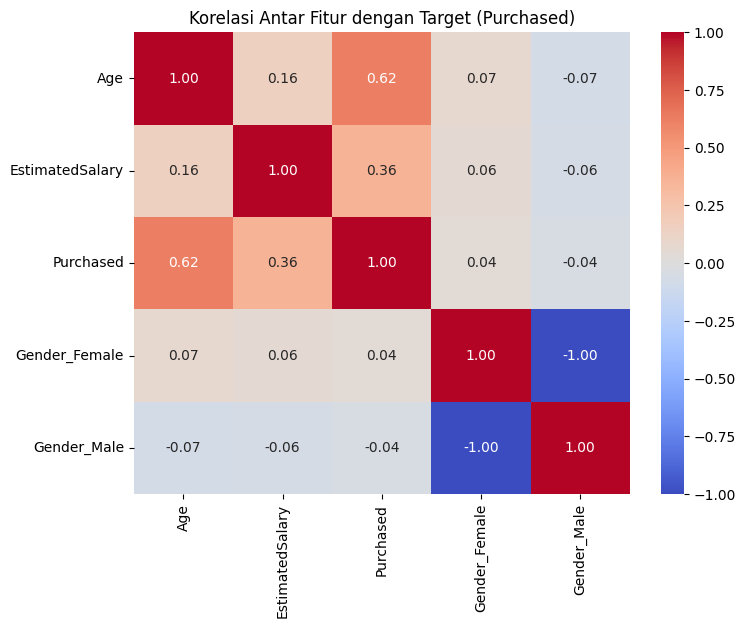


Korelasi spesifik terhadap kolom 'Purchased':
Purchased          1.000000
Age                0.622454
EstimatedSalary    0.362083
Gender_Female      0.042469
Gender_Male       -0.042469
Name: Purchased, dtype: float64


In [ ]:
# Kita buang 'User ID' dulu dan ubah 'Gender' jadi angka agar bisa dihitung korelasinya
df_for_corr = pd.get_dummies(df.drop('User ID', axis=1, errors='ignore'))

# Menghitung korelasi
korelasi = df_for_corr.corr()

# Visualisasi korelasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Fitur dengan Target (Purchased)")
plt.show()

# Menampilkan nilai korelasi spesifik ke kolom 'Purchased'
print("\nKorelasi spesifik terhadap kolom 'Purchased':")
print(korelasi['Purchased'].sort_values(ascending=False))

## Train Test Split

In [ ]:
# Mengambil 2 fitur utama (Age & EstimatedSalary) untuk X agar bisa divisualisasikan 2D
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Split data (75% Train, 25% Test - standar umum untuk visualisasi algoritma ini)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Feature Scaling (Wajib agar skala Age dan Salary seimbang di grafik & model)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (300, 2)
Ukuran X_test: (100, 2)


## Buat klasifier dan Lakukan Training

## DecisionTree Classifier

In [ ]:
# Membuat dan melatih model Decision Tree
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Prediksi dan akurasi
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"Akurasi Decision Tree: {dt_acc * 100:.2f}%")

Akurasi Decision Tree: 83.00%


### Melakukan Visualisasi Data Train dan Data Test

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


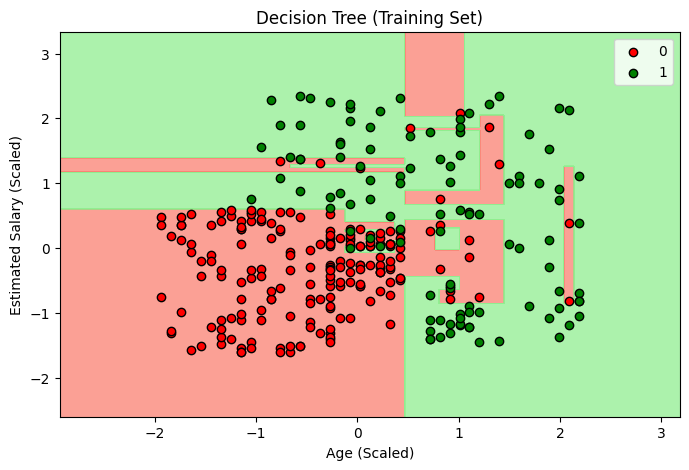

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


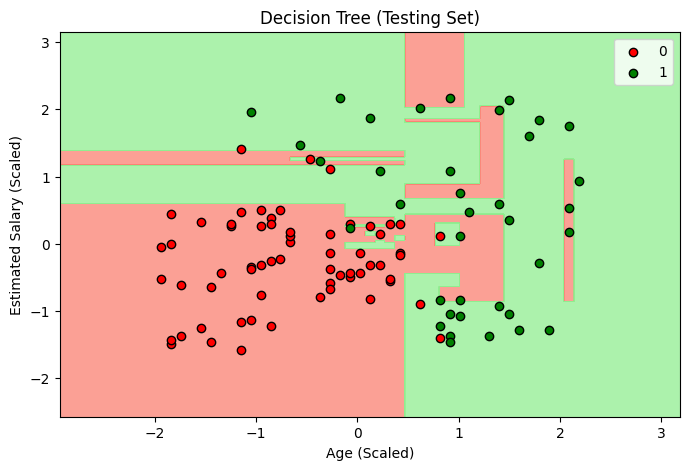

In [ ]:
# Fungsi bantuan untuk visualisasi agar kode tidak terlalu panjang diulang-ulang
def plot_decision_boundary(X_set, y_set, classifier, title):
    X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                         np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.75, cmap=ListedColormap(('salmon', 'lightgreen')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c=ListedColormap(('red', 'green'))(i), label=j, edgecolor='black')
    plt.title(title)
    plt.xlabel('Age (Scaled)')
    plt.ylabel('Estimated Salary (Scaled)')
    plt.legend()
    plt.show()

# Visualisasi Data Train (Decision Tree)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_train, y_train, dt_model, 'Decision Tree (Training Set)')

# Visualisasi Data Test (Decision Tree)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_test, y_test, dt_model, 'Decision Tree (Testing Set)')

## Logistic Regression

In [ ]:
# Membuat dan melatih model Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Prediksi dan akurasi
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Akurasi Logistic Regression: {lr_acc * 100:.2f}%")

Akurasi Logistic Regression: 86.00%


### Melakukan Visualisasi Data Train dan Data Test

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


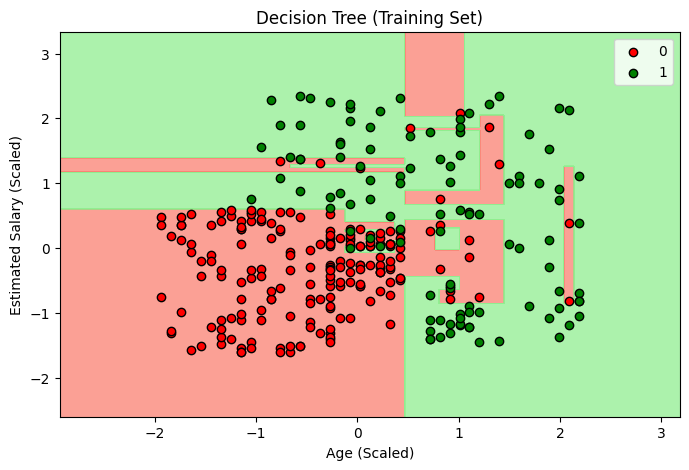

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


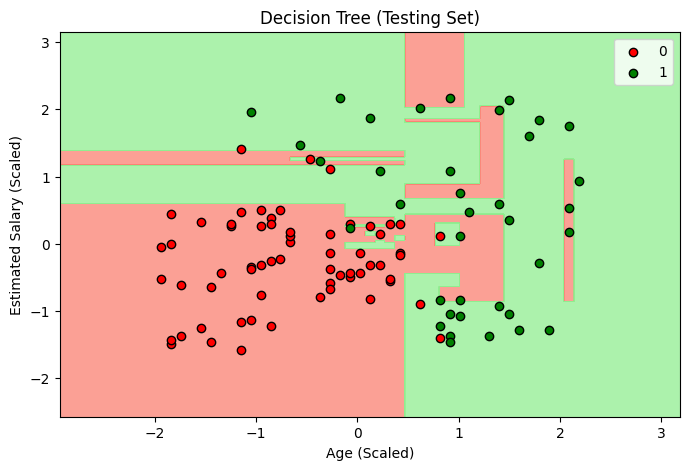

In [ ]:
# Fungsi bantuan untuk visualisasi agar kode tidak terlalu panjang diulang-ulang
def plot_decision_boundary(X_set, y_set, classifier, title):
    X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                         np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.75, cmap=ListedColormap(('salmon', 'lightgreen')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c=ListedColormap(('red', 'green'))(i), label=j, edgecolor='black')
    plt.title(title)
    plt.xlabel('Age (Scaled)')
    plt.ylabel('Estimated Salary (Scaled)')
    plt.legend()
    plt.show()

# Visualisasi Data Train (Decision Tree)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_train, y_train, dt_model, 'Decision Tree (Training Set)')

# Visualisasi Data Test (Decision Tree)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_test, y_test, dt_model, 'Decision Tree (Testing Set)')

Melakukan Visualisasi Data Train dan Data Test (Logistic Regression)

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


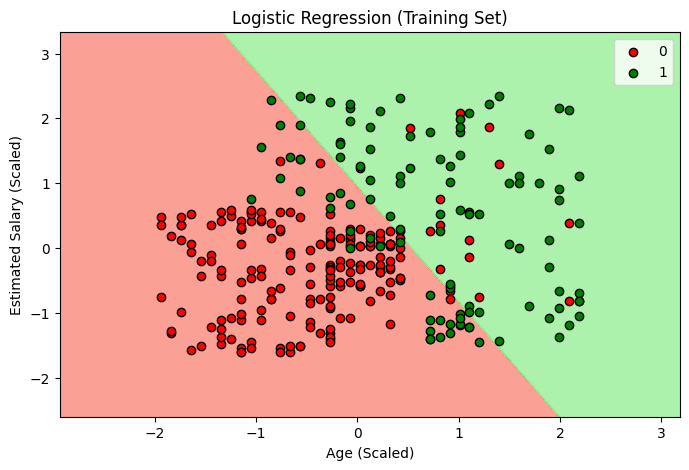

/tmp/ipykernel_660/2540250216.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


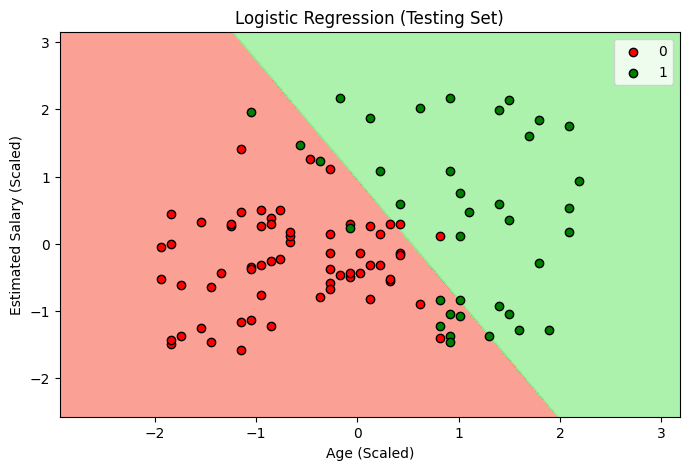

In [ ]:
# Kita menggunakan fungsi plot_decision_boundary yang sudah dibuat di Langkah 8

# Visualisasi Data Train (Logistic Regression)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_train, y_train, lr_model, 'Logistic Regression (Training Set)')

# Visualisasi Data Test (Logistic Regression)
plt.figure(figsize=(8,5))
plot_decision_boundary(X_test, y_test, lr_model, 'Logistic Regression (Testing Set)')